Employer Attrition Project.
🎯 Goal:

Predict whether an employee will leave a company (1) or stay (0)

In [2]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn._config import set_config
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, train_test_split

Precision score: 91.67
Recall score: 91.67
Classification report:               precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.92      0.92      0.92        12

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



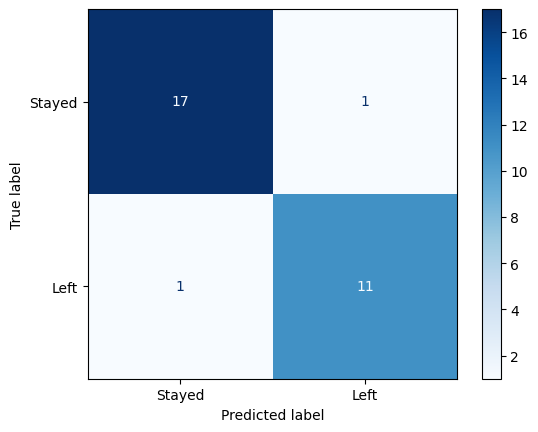

In [19]:
set_config(transform_output='pandas')

df = pd.read_csv("employee.csv")

X = df.drop(columns=['left'])
y = df['left']

# divide sets.

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.2)

# preprocess data
categorical_features = X.select_dtypes(include=['str', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

preprocess = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(sparse_output=False), categorical_features),
        ("scaler", StandardScaler(), numerical_features)
    ]
)

# pipeline

pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(random_state=42))
])

# grid search
model = GridSearchCV(
    estimator=pipe,
    param_grid={
        'model__random_state': [42],
        "model__class_weight": [{0: 5, 1: 10}],
    },
    scoring=['precision', 'recall', 'f1'],
    refit='recall',
    cv=5,
    error_score='raise'
)

# fit or train model
model.fit(X_train, y_train)

# predict
model_prediction = model.predict(X_test)

# evaluate model
# accuracy score
accuracy = precision_score(y_test, model_prediction)
print(f'Precision score: {accuracy * 100:.2f}')

# recall score
recall = recall_score(y_test, model_prediction)
print(f'Recall score: {recall * 100:.2f}')

# classification
classification = classification_report(y_test, model_prediction)
print(f'Classification report: {classification}')

cm = confusion_matrix(y_test, model_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])

disp.plot(cmap='Blues')
plt.show()

My model had a recall score of 100 which means something is wrong, most probably the model was overfitting itsellf or just guessing instead of learning.

So i had to adjust the classweight to be become balanced instead of making the class weight to be 0:1, 1:50, which was why my model was just guessing.

Also my model was really strong because it correctly predicted 17 of 18 of the employees that stayed and correctly cuaght 11 of 12 employees that were about to leave

RANDOM FOREST CLASSIFIER

Precision score: 83.33
Recall score: 83.33
Classification report:               precision    recall  f1-score   support

           0       0.89      0.89      0.89        18
           1       0.83      0.83      0.83        12

    accuracy                           0.87        30
   macro avg       0.86      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30



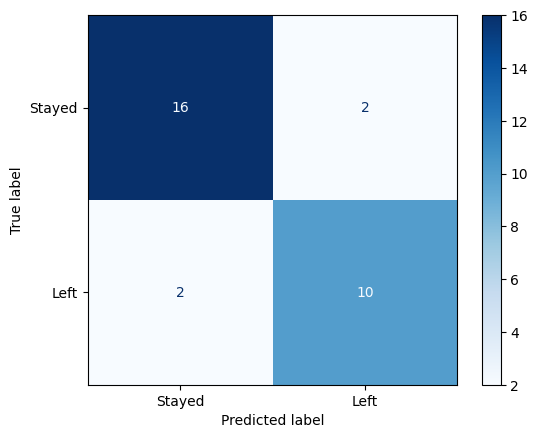

In [15]:
set_config(transform_output="pandas")

df = pd.read_csv("employee.csv")

X = df.drop(columns=["left"])
y = df["left"]

# divide sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y, test_size=0.2
)

categorical_features = X.select_dtypes(include=["str", "category"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(sparse_output=False), categorical_features),
    ],
    remainder="passthrough",
)
# pipeline

pipe = Pipeline(
    [("prep", preprocess), ("model", RandomForestClassifier(random_state=42))]
)

# grid search
model = GridSearchCV(
    estimator=pipe,
    param_grid={
        "model__n_estimators": [20],
        "model__max_depth": [10, 15],
        "model__class_weight": [{0: 5, 1: 10}],
    },
    scoring=["precision", "recall", "f1"],
    refit="recall",
    cv=5,
    error_score="raise",
)

# fit or train model
model.fit(X_train, y_train)

# predict
model_prediction = model.predict(X_test)

# evaluate model
# accuracy score
accuracy = precision_score(y_test, model_prediction)
print(f"Precision score: {accuracy * 100:.2f}")

# recall score
recall = recall_score(y_test, model_prediction)
print(f"Recall score: {recall * 100:.2f}")

# classification
classification = classification_report(y_test, model_prediction)
print(f"Classification report: {classification}")

cm = confusion_matrix(y_test, model_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Left"])

disp.plot(cmap="Blues")
plt.show()